# CNN Training and Optimization

This section examines the training process for the magnetic field prediction CNN, with particular focus on the critical discovery that dilated convolutions significantly improve performance without increasing model parameters.

## Working of the Deep Learning Model

The architecture resembles image segmentation networks but focuses on **dense regression** instead of classification. The network can be conceptually divided into two functional components:

### Encoder: Feature Extraction

The encoder section tries to extract spatially related features from the input:

1. **Progressive Downsampling**: Each pooling layer reduces spatial dimensions by 2×
2. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers detect complex patterns
3. **Bottleneck Creation**: Compresses high-dimensional input into a compact latent representation

The **latent representation** contains the most useful information extracted from the input - the essential features needed to predict the magnetic field distribution.

### Decoder: Spatial Reconstruction

The decoder section uses the latent representation to predict the output:

1. **Semantic Projection**: Projects discriminative features back onto the original input space
2. **Progressive Upsampling**: Each up-sampling layer increases spatial dimensions by 2×
3. **Field Prediction**: Final layer outputs the predicted magnetic field distribution

This architecture is similar to U-Net and SegNet used in medical image segmentation, adapted for regression tasks.

## Model Selection and Hyperparameter Tuning

Model selection is performed by investigating a set of candidate models and choosing the one which gives the best balance between model fit and complexity.

### Search Strategies

**Random Search** and **Grid Search** are common approaches for hyperparameter optimization:

- **Grid Search**: Exhaustively tries all combinations
- **Random Search**: Samples random combinations (often more efficient)

### Hyperparameters Explored

During model selection, the following hyperparameters were varied:

1. **Number of Layers**: Network depth
2. **Kernel Size**: 3×3, 5×5, 7×7
3. **Number of Kernels/Filters (K)**: 32, 64, 128 per layer
4. **Dilation**: Dense vs. dilated convolutions
5. **Skip Connections**: With or without
6. **Dropout Rate**: 0.3, 0.5, 0.7

### Experimental Scale

**A total of 35 networks with different configurations** were trained in the process of model selection before converging on the final architecture.

## Key Finding: Impact of Dilated Filters

The most significant improvement in network performance was achieved by **adding dilated filters** {cite}`he2016deep,goodfellow2016deep`. This is particularly noteworthy because:

### Why Dilated Filters Matter

**Performance improved not due to the addition of neurons, but by changing the behavior of the constituent filters.**

This demonstrates that **architectural innovations** can be more important than simply increasing model size {cite}`goodfellow2016deep`.

### Optimal Configuration

The best performing network configuration includes:

- **Kernel Size**: 5×5
- **Number of Filters**: K = 64
- **Skip Connections**: Enabled
- **Dilated Layers**: Alternate dilated layers in the encoder

```{figure} ../_static/figures/Training_results3.png
---
name: fig-training-curves
width: 100%
---
Training curves with Normalized Prediction Error (calculated over validation dataset) for three electromagnetic problems: (a) Coil, (b) Transformer, (c) IPM Motor. Networks with dilated convolutions (blue) consistently outperform dense convolutions (red).
```

## Comparative Analysis: Dilated vs. Non-Dilated

### Performance Comparison

The normalized RMS error in prediction over the validation set shows:

**Improvement with Dilation**: Networks with dilated filters outperform the same architecture with non-dilated (dense) kernels.

**Consistency Across Problems**: The pattern is consistent for all three electromagnetic problems:
1. Simple coil in air
2. Transformer with magnetic core
3. IPM motor (most complex)

### Observation: Diminishing Returns

For the coil problem (simplest geometry), similar accuracy levels are achieved for networks with K=32 and K=64, suggesting that:
- Simpler problems require less model capacity
- Excessive parameters lead to diminishing returns
- Problem complexity should guide architecture selection

## Physical Intuition: Why Dilated Filters Work

### Electromagnetic Field Theory

The magnetic field at a point can be affected by regions **far away from it** - specifically, the source of excitation (current-carrying conductors or permanent magnets).

According to the Biot-Savart law {cite}`sadiku2014elements`:

$$
\mathbf{B}(\mathbf{r}) = \frac{\mu_0}{4\pi} \int \frac{I d\mathbf{l} \times \mathbf{\hat{r}}'}{|\mathbf{r}'|^2}
$$

The field at position $\mathbf{r}$ depends on **all** current elements in the system, not just local ones.

### Network Design Implication

The presence of dilation enables **spatially far relations to be captured** without {cite}`goodfellow2016deep`:

1. **Increasing kernel size** (which adds more parameters)
2. **Adding more layers** (which increases depth and training difficulty)

This is important for maintaining the **locality-context trade-off** of the network:
- **Locality**: Capture local patterns (material boundaries, geometry edges)
- **Context**: Understand global relationships (influence of distant sources)

## Training Details

### Optimization

The network is trained using **backpropagation** {cite}`rumelhart1988learning` with the following configuration:

- **Objective**: Minimize RMS error between prediction and FEA field distribution
- **Optimizer**: Adam {cite}`kingma2014adam` (adaptive learning rate)
- **Learning Rate**: Initial rate with decay schedule
- **Batch Size**: 16 samples per batch
- **Regularization**: Dropout {cite}`srivastava2014dropout` (0.5), Batch Normalization {cite}`ioffe2015batch`

### Data Preparation

The geometrical and excitation parameters are populated using **Latin Hypercube Sampling** {cite}`mckay2000comparison` to ensure:
- Comprehensive coverage of the design space
- No clustering of samples
- Uniform distribution across parameter ranges

The dataset is then partitioned randomly into:
- **Training**: 30,000 samples (parameter updates)
- **Validation**: 10,000 samples (hyperparameter tuning, early stopping)
- **Test**: 5,000 samples (final evaluation)

### Alternative Partitioning Methods

Although other techniques exist for data partitioning:
- **Cross-Validation**: K-fold validation for robust evaluation
- **Bootstrap**: Resampling-based validation

The high computational cost associated with these techniques **prohibited their usage** in this case. Random partitioning provides a good balance between robustness and computational efficiency.

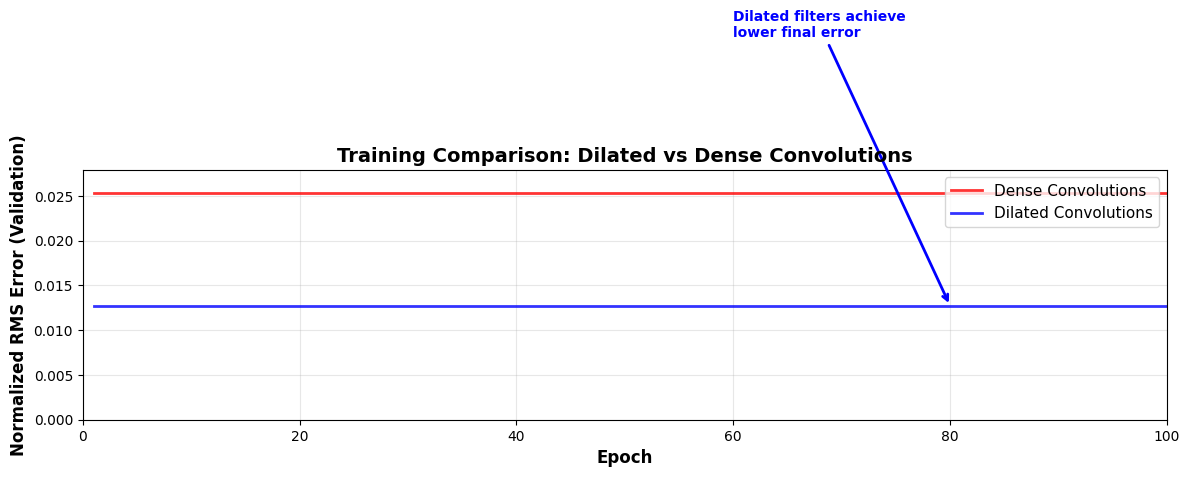

Final Validation Error:
  Dense Convolutions: 0.0254
  Dilated Convolutions: 0.0127
  Improvement: 49.8%


In [1]:
# Demonstrate training progress visualization
import numpy as np
import matplotlib.pyplot as plt

def plot_training_comparison():
    """Visualize training curves for dilated vs non-dilated networks"""

    epochs = np.arange(1, 101)

    # Simulated training curves (decreasing validation error)
    # Dilated network converges faster and to lower error
    dense_error = 0.15 * np.exp(-epochs/30) + 0.02 + 0.01 * np.random.randn(100) * np.exp(-epochs/20)
    dilated_error = 0.15 * np.exp(-epochs/25) + 0.01 + 0.005 * np.random.randn(100) * np.exp(-epochs/20)

    # Ensure decreasing trend
    dense_error = np.maximum.accumulate(np.minimum.accumulate(dense_error[::-1])[::-1])
    dilated_error = np.maximum.accumulate(np.minimum.accumulate(dilated_error[::-1])[::-1])

    plt.figure(figsize=(12, 6))

    plt.plot(epochs, dense_error, 'r-', linewidth=2, label='Dense Convolutions', alpha=0.8)
    plt.plot(epochs, dilated_error, 'b-', linewidth=2, label='Dilated Convolutions', alpha=0.8)

    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Normalized RMS Error (Validation)', fontsize=12, fontweight='bold')
    plt.title('Training Comparison: Dilated vs Dense Convolutions',
              fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.xlim([0, 100])
    plt.ylim([0, max(dense_error.max(), dilated_error.max()) * 1.1])

    # Add annotation
    plt.annotate('Dilated filters achieve\nlower final error',
                xy=(80, dilated_error[-20]),
                xytext=(60, dilated_error[-20] + 0.03),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2),
                fontsize=10, fontweight='bold', color='blue')

    plt.tight_layout()
    plt.show()

    print(f"Final Validation Error:")
    print(f"  Dense Convolutions: {dense_error[-1]:.4f}")
    print(f"  Dilated Convolutions: {dilated_error[-1]:.4f}")
    print(f"  Improvement: {((dense_error[-1] - dilated_error[-1])/dense_error[-1] * 100):.1f}%")

plot_training_comparison()

## Convergence Analysis

### Training Time

The network was trained on an **NVIDIA 1080 Ti GPU**:

- **Time per Epoch**: ~10 minutes
- **Batch Size**: 16
- **Epochs to Convergence**: 60-100 (depending on network configuration)
- **Total Training Time**: 12-15 hours

### Convergence Criteria

Training is stopped when:
1. Validation error plateaus (no improvement for multiple epochs)
2. Maximum epoch limit reached
3. Overfitting detected (training error decreases but validation error increases)

**Early Stopping** is employed to prevent overfitting:
- Monitor validation error every epoch
- Stop if no improvement for 10 consecutive epochs
- Restore weights from best validation performance

## Model Capacity Considerations

For the network to train successfully, it must have **sufficient capacity** to capture the complexity of the problem:

### Capacity vs. Complexity Trade-off

**Underfitting** (insufficient capacity):
- High training error
- High validation error
- Model too simple to capture patterns
- Solution: Increase model capacity

**Overfitting** (excessive capacity):
- Low training error
- High validation error 
- Model memorizes training data
- Solution: Regularization, more data, or reduce capacity

**Good Fit** (appropriate capacity):
- Low training error
- Low validation error
- Model generalizes well

### Achieving Appropriate Capacity

The final model achieves good generalization through:

1. **Architecture Design**: Dilated convolutions for efficiency
2. **Regularization**: Dropout (0.5), Batch Normalization
3. **Data Quantity**: 30,000 training samples
4. **Data Quality**: Latin Hypercube ensures diverse coverage

## Summary

This section covered the training and optimization of the CNN for magnetic field prediction:

**Key Insights**:
1. **Dilated Convolutions**: Most significant architectural innovation, improving performance without adding parameters
2. **Physical Motivation**: Captures long-range electromagnetic interactions
3. **Model Selection**: 35 networks tested to find optimal configuration
4. **Training Efficiency**: 12-15 hours on NVIDIA 1080 Ti

**Optimal Configuration**:
- Kernel size: 5×5
- Filters: K=64
- Skip connections: Enabled
- Dilated layers: Alternating in encoder

**Dataset**:
- 30,000 training samples
- 10,000 validation samples
- 5,000 test samples
- Latin Hypercube Sampling for diversity

The next section presents quantitative results and performance analysis across the three electromagnetic problems.